Implementing and visualizing the probabilistic nature of the Naive Bayes algorithm.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from naive_bayes import MyGaussianNB
from sklearn.naive_bayes import GaussianNB

## 1. Load Data (Moons)
We use the 'Moons' dataset with noise. This is a non-linear dataset where two classes form interleaving crescents. 
Gaussian Naive Bayes assumes classes are 'blobs' (Normal distribution), so it will struggle to fit these crescents perfectly. 
This is good! It proves our model isn't overfitting.

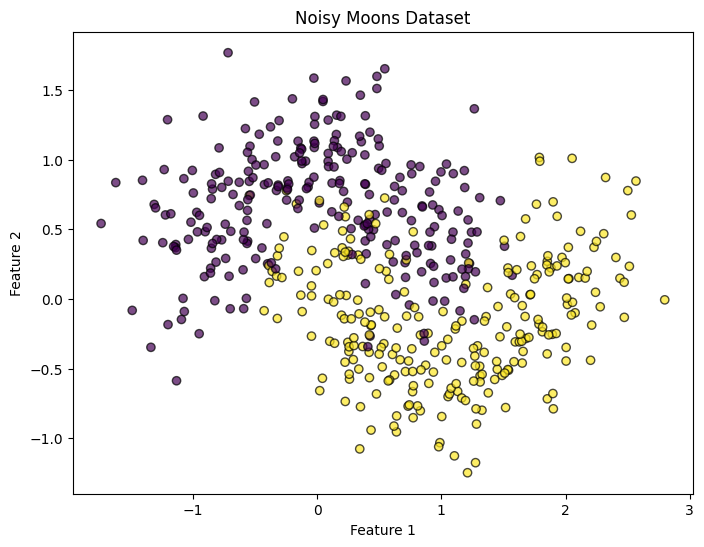

In [8]:
# Generate Non-linear Data
X, y = datasets.make_moons(n_samples=500, noise=0.3, random_state=42)

plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', edgecolor='k', alpha=0.7)
plt.title("Noisy Moons Dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## 2. Train Custom Model

In [9]:
model = MyGaussianNB()
model.fit(X_train, y_train)
preds = model.predict(X_test)

acc = model.accuracy(y_test, preds)
print(f"Custom Model Accuracy: {acc:.4f}")

Custom Model Accuracy: 0.8500


## 3. Compare with Sklearn
Let's see if our implementation matches the standard library.

In [11]:
sk_model = GaussianNB()
sk_model.fit(X_train, y_train)
sk_preds = sk_model.predict(X_test)
sk_acc = sk_model.score(X_test, y_test)

print(f"Sklearn Model Accuracy: {sk_acc:.4f}")
print(f"Custom Model Accuracy: {acc:.4f}")

Sklearn Model Accuracy: 0.8500
Custom Model Accuracy: 0.8500


## 4. Visualize Decision Boundaries
Since Gaussian NB assumes a Gaussian distribution, the decision boundary is usually quadratic (curved). Let's see how it tries to separate the moons.
   

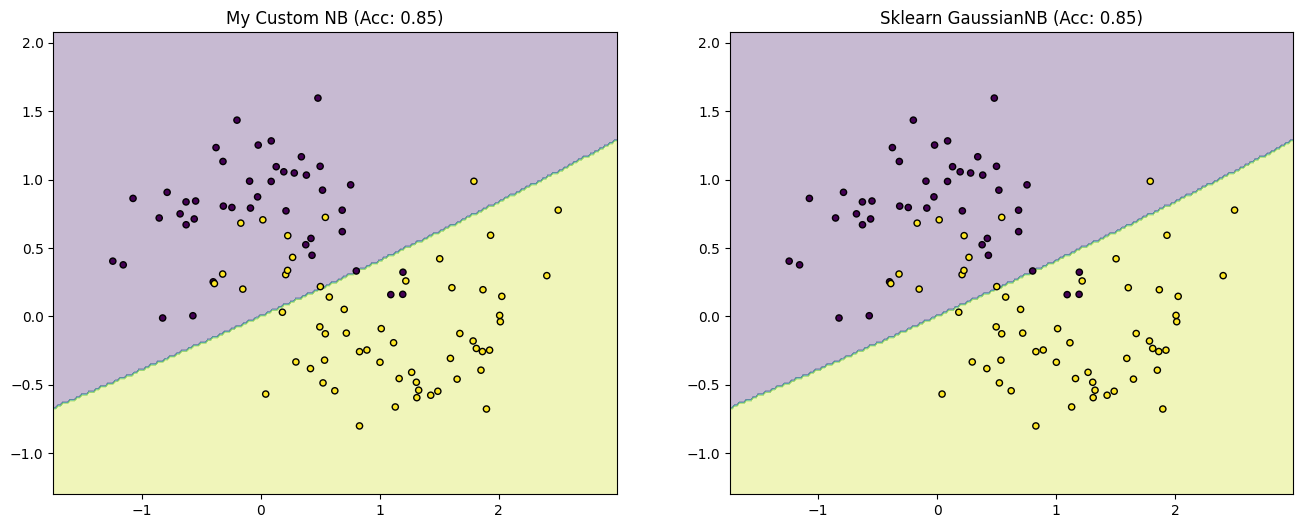

In [12]:
def plot_decision_boundary(model, X, y, title, ax):
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Predict on meshgrid
    if hasattr(model, 'predict'):
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    else:
        Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
        
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, alpha=0.3, cmap='viridis')
    ax.scatter(X[:, 0], X[:, 1], c=y, s=20, edgecolor='k', cmap='viridis')
    ax.set_title(title)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_decision_boundary(model, X_test, y_test, f"My Custom NB (Acc: {acc:.2f})", axes[0])
plot_decision_boundary(sk_model, X_test, y_test, f"Sklearn GaussianNB (Acc: {sk_acc:.2f})", axes[1])
plt.show()

### Interpretation
Notice how the decision boundary is smooth and curved, but it **cannot** capture the spiral shape of the moons perfectly. It tries to draw a boundary between two 'blobs'.

This confirms our model is behaving like a true Gaussian Naive Bayes classifier: it works well when data is normally distributed, but has limitations on complex, non-linear shapes like moons.
   